# Automatic differentiation with backward mode

> **NOTE**
>
> autodiff system in `pespace` and `tiwave` is still under active development. If errors occur when running this notebook, try using the commit tagged [`autodiff`](https://github.com/nnrui/pespace/tree/autodiff) may solve the problem.


In [1]:
import numpy as np
from matplotlib import pyplot as plt
import bilby

import taichi as ti
ti.init(
    arch=ti.cpu,
    default_fp=ti.f64,
    cpu_max_num_threads=1,
    offline_cache=False,
    debug=True,
    unrolling_limit=0
)


[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.10.19
[Taichi] Starting on arch=x64


[I 02/02/26 11:46:41.873 86535] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


In [2]:
from pespace.detector.antenna import InterferometerAntenna, FDResponseModelMarset2018
from pespace.detector.tdi import TDIChannelData, FDMichelsonConstantEqualArm
from pespace.detector.orbit import KaplerianHeliocentric
from tiwave.waveforms import IMRPhenomXAS


In [3]:
tdi_gen = "2.0"
tdi_chan = ("A", "E", "T")
DAYJUL_SI = 86400.0

delta_time = 10
f_min = 1e-4
f_max = 0.5*(1/delta_time)
f_ref = f_min
t_start = 0.0

num_tsamples = 2 ** np.ceil(np.log2(30 * DAYJUL_SI/delta_time)) # two weeks
duration = num_tsamples * delta_time
before_tc = 0.8 * duration
after_tc = 0.2 * duration
tc = t_start + before_tc
print("sample num: ", num_tsamples)
print("duration: ", duration)
print("duration(day): ", duration/DAYJUL_SI)
print("tc: ", tc)


params = dict(
    total_mass=3e6,
    mass_ratio=0.6,
    chi_1=0.75,
    chi_2=0.62,
    luminosity_distance=56000.0,
    inclination=0.4,
    reference_phase=1.3,
    ecliptic_longitude=1.375,
    ecliptic_latitude=-1.2108,
    polarization=2.659,
    coalescence_time=tc,
)
params = bilby.gw.conversion.generate_component_masses(params)
display(params)
params.pop('total_mass')
params.pop('mass_ratio')



sample num:  262144.0
duration:  2621440.0
duration(day):  30.340740740740742
tc:  2097152.0


{'total_mass': 3000000.0,
 'mass_ratio': 0.6,
 'chi_1': 0.75,
 'chi_2': 0.62,
 'luminosity_distance': 56000.0,
 'inclination': 0.4,
 'reference_phase': 1.3,
 'ecliptic_longitude': 1.375,
 'ecliptic_latitude': -1.2108,
 'polarization': 2.659,
 'coalescence_time': np.float64(2097152.0),
 'mass_1': 1875000.0,
 'mass_2': 1125000.0}

0.6

In [4]:
tdi_data = TDIChannelData()
tdi_data.set_fd_data_from_zero(
    tdi_chan,
    duration,
    delta_time,
    start_time=t_start,
    minimum_frequency=f_min,
    maximum_frequency=f_max,
)
tdi_data.set_fd_noise_power_density_from_model("LISA_SciRDv1", tdi_generation=tdi_gen)

orbit_model = KaplerianHeliocentric(2.5e9, 0.0, 0.0)
response_model = FDResponseModelMarset2018()
tdi_combination = FDMichelsonConstantEqualArm(generation=tdi_gen, orthogonal=True)

lisa = InterferometerAntenna(
    name="lisa",
    tdi_data=tdi_data,
    orbit_model=orbit_model,
    response_model=response_model,
    tdi_combination=tdi_combination,
    needs_grad=True,
)
waveform_tiw = IMRPhenomXAS(
    tdi_data.frequency_samples, 
    f_ref, 
    needs_grad=True,
    )
waveform_tiw.update_waveform(params)
lisa.update_detector_response(
    waveform_tiw.waveform_container,
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    params["coalescence_time"],
)


/home/nrui/disk_ext/workspace/tiwave/tiwave/waveforms/base_waveform.py:74: UserWarning: check_parameters is disable, make sure all parameters passed in are valid.
  warnings.warn(


In [5]:
# # abs
# plt.figure()
# plt.loglog(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     np.abs(lisa.tdi_response_numpy["A"]),
#     label="A",
# )
# plt.loglog(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     np.abs(lisa.tdi_response_numpy["E"]),
#     label="E",
# )
# plt.loglog(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     np.abs(lisa.tdi_response_numpy["T"]),
#     label="T",
# )
# plt.xlim(f_min, f_max)
# plt.legend()

# # real part
# plt.figure()
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["A"].real,
#     label="A real",
# )
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["E"].real,
#     label="E real",
# )
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["T"].real,
#     label="T real",
# )
# plt.xlim(f_min, f_max)
# plt.legend()

# # imag part
# plt.figure()
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["A"].imag,
#     label="A imag",
# )
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["E"].imag,
#     label="E imag",
# )
# plt.semilogx(
#     lisa.tdi_data.data_info.frequency_samples_array,
#     lisa.tdi_response_numpy["T"].imag,
#     label="T imag",
# )
# plt.xlim(f_min, f_max)
# plt.legend()

In [6]:
num = 10
iota_array = np.linspace(0.1, np.pi-0.1, num)


psds = lisa.tdi_data.fd_noise_power_density_numpy
delta_freq = lisa.tdi_data.data_info.delta_frequency


def get_rho_numpy(response, psds, df):
    rho2 = 0.0
    for chan in response.keys():
        rho2 += np.vdot(response[chan], response[chan]/psds[chan]).real * 4.0 * df

    return np.sqrt(rho2)


def get_d_rho_numpy(d_response, response, psds, df):
    rho = get_rho_numpy(response, psds, df)

    d_rho2 = 0.0
    for chan in response.keys():
        d_rho2 += np.vdot(d_response[chan], response[chan]/psds[chan]).real * df * 8
    
    return d_rho2/(2*rho)


In [7]:
# symbolic differential
drho_diota_sd = np.zeros_like(iota_array)

@ti.kernel
def change_waveform_to_derivative(waveform_container: ti.template(), iota: float):
    cos_iota = ti.cos(iota)
    sin_iota = ti.sin(iota)
    for i in waveform_container:
        waveform_container[i].plus *= -(2*sin_iota*cos_iota)/(1+cos_iota*cos_iota)
        waveform_container[i].cross *= -sin_iota/cos_iota

for idx in range(num):
    params_sample = params.copy()
    params_sample['inclination'] = iota_array[idx]
    waveform_tiw.update_waveform(params_sample)
    lisa.update_detector_response(waveform_tiw.waveform_container,
                                  params_sample['ecliptic_longitude'],
                                  params_sample['ecliptic_latitude'],
                                  params_sample['polarization'],
                                  params_sample['coalescence_time'],
                                  )
    response = lisa.tdi_response_numpy

    change_waveform_to_derivative(waveform_tiw.waveform_container, params_sample['inclination'])
    lisa.update_detector_response(waveform_tiw.waveform_container,
                                  params_sample['ecliptic_longitude'],
                                  params_sample['ecliptic_latitude'],
                                  params_sample['polarization'],
                                  params_sample['coalescence_time'],
                                  )
    d_response = lisa.tdi_response_numpy
    
    d_rho = get_d_rho_numpy(d_response, response, psds, delta_freq)

    drho_diota_sd[idx] = d_rho

drho_diota_sd

array([ -186.78885712,  -744.5647822 , -1120.45507   , -1188.58411835,
        -637.48134677,   642.05047074,  1191.29076756,  1122.63027232,
         746.01518537,   187.15546285])

In [8]:
# numerical differential
drho_diota_nd_list = []
step_list = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12]
for step in step_list:
    drho_diota_nd = np.zeros_like(iota_array)

    for idx in range(num):
        params_left = params.copy()
        params_left['inclination'] = iota_array[idx] - step
        waveform_tiw.update_waveform(params_left)
        lisa.update_detector_response(waveform_tiw.waveform_container,
                                      params_left['ecliptic_longitude'],
                                      params_left['ecliptic_latitude'],
                                      params_left['polarization'],
                                      params_left['coalescence_time'],
                                      )
        response_left = lisa.tdi_response_numpy
        rho_left = get_rho_numpy(response_left, psds, delta_freq)

        params_right = params.copy()
        params_right['inclination'] = iota_array[idx] + step
        waveform_tiw.update_waveform(params_right)
        lisa.update_detector_response(waveform_tiw.waveform_container,
                                      params_right['ecliptic_longitude'],
                                      params_right['ecliptic_latitude'],
                                      params_right['polarization'],
                                      params_right['coalescence_time'],
                                      )
        response_right = lisa.tdi_response_numpy
        rho_right = get_rho_numpy(response_right, psds, delta_freq)

        drho_diota_nd[idx] = (rho_right - rho_left) / (2*step)
    drho_diota_nd_list.append(drho_diota_nd)

drho_diota_nd_list

[array([ -186.78150276,  -744.53597202, -1120.40875427, -1188.49544728,
         -637.30592251,   641.87493609,  1191.20229988,  1122.58390764,
          745.98631507,   187.14809241]),
 array([ -186.78885639,  -744.56477931, -1120.45506536, -1188.58410948,
         -637.48132923,   642.05045318,  1191.29075872,  1122.63026769,
          746.01518248,   187.15546211]),
 array([ -186.78885726,  -744.56478217, -1120.45507001, -1188.58411827,
         -637.4813467 ,   642.05047073,  1191.29076768,  1122.63027256,
          746.01518565,   187.15546287]),
 array([ -186.78886136,  -744.56478387, -1120.45506739, -1188.58410474,
         -637.48134949,   642.05046897,  1191.29076097,  1122.63027177,
          746.01518918,   187.1554673 ]),
 array([ -186.78747438,  -744.56579569, -1120.45768219, -1188.58338283,
         -637.4818895 ,   642.05096351,  1191.29083487,  1122.63023766,
          746.014166  ,   187.15809347]),
 array([ -186.78747438,  -744.53510024, -1120.38378575, -1188.70957522

In [13]:
# automatic differential
drho_diota_ad = np.zeros_like(iota_array)
rho2_ti = ti.field(dtype=ti.f64, shape=(), needs_grad=True)
rho_ti = ti.field(dtype=ti.f64, shape=(), needs_grad=True)


@ti.kernel
def get_rho_taichi():
    rho_ti[None] = ti.sqrt(rho2_ti[None])


@ti.kernel
def get_rho2_taichi():
    # reset rho2_ti outside of the kernel
    for i in lisa.tdi_response:
        inner_product = 0.0
        for chan in ti.static(lisa.tdi_data.data_info.channels):
            inner_product += (lisa.tdi_response[i][chan].norm_sqr()/lisa.tdi_data.fd_noise_power_density[i][chan] * 4.0 * delta_freq)
        ti.atomic_add(rho2_ti[None], inner_product)

for idx in range(num):
    params_sample = params.copy()
    params_sample['inclination'] = iota_array[idx]
    
    rho2_ti[None] = 0.0
    rho_ti[None] = 0.0

    with ti.ad.Tape(loss=rho_ti, clear_gradients=True):
        waveform_tiw.update_waveform(params_sample)
        lisa.update_detector_response(
            waveform_tiw.waveform_container,
            params_sample['ecliptic_longitude'],
            params_sample['ecliptic_latitude'],
            params_sample['polarization'],
            params_sample['coalescence_time'],
            )
        get_rho2_taichi()
        get_rho_taichi()
    drho_diota_ad[idx] = waveform_tiw._params.iota.grad[None]

drho_diota_ad

array([ -186.78885712,  -744.5647822 , -1120.45507   , -1188.58411835,
        -637.48134677,   642.05047074,  1191.29076756,  1122.63027232,
         746.01518537,   187.15546285])

In [14]:
import matplotlib 
fig_width_pt = 3*246.0                  # Get this from LaTeX using \showthe\columnwidth
inches_per_pt = 1.0/72.27               # Convert pt to inch
golden_mean = (np.sqrt(5)-1.0)/2.0      # Aesthetic ratio
fig_width = fig_width_pt*inches_per_pt  # width in inches
fig_height = fig_width*golden_mean      # height in inches
fig_size =  [fig_width,fig_height]
plot_params = {'axes.labelsize': 24,
          'font.family': 'serif',
          'font.serif': 'Computer Modern',
          'font.size': 24,
          'legend.fontsize': 20,
          'xtick.labelsize': 18,
          'ytick.labelsize': 18,
          'axes.grid' : False,
          'text.usetex': True,
          'savefig.dpi' : 100,
          'lines.markersize' : 14,
          'figure.figsize': fig_size}
matplotlib.rcParams.update(plot_params)
import os
os.environ['PATH'] = "/home/nrui/.local/texlive/2025/bin/x86_64-linux:" + os.environ['PATH']

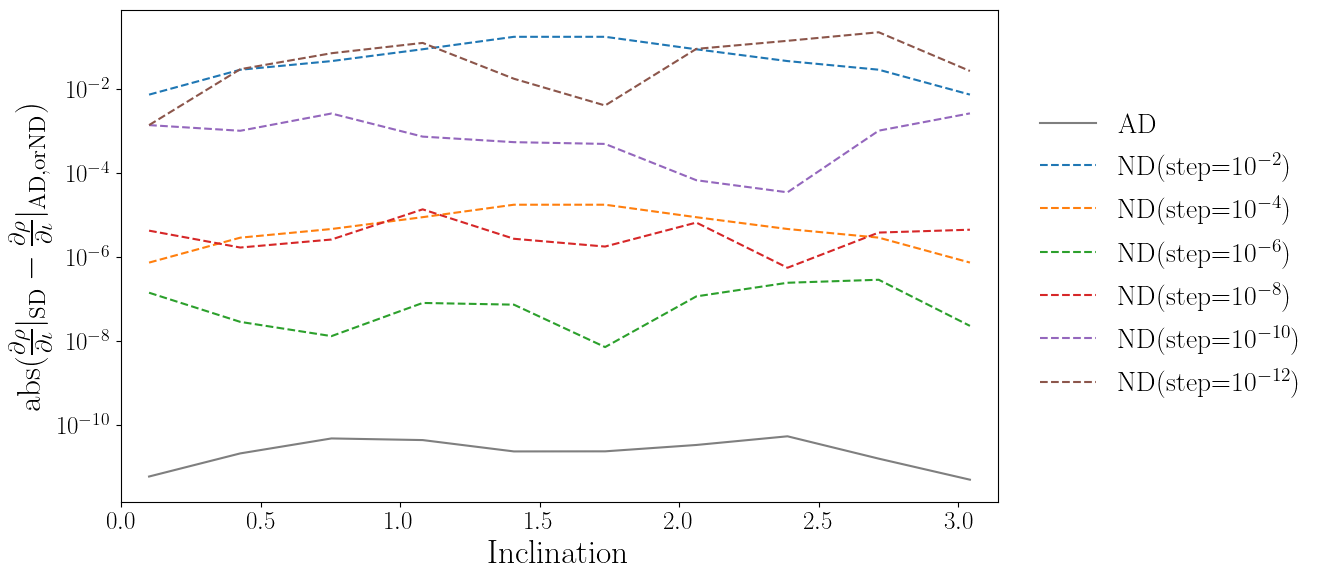

In [15]:
color_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
label_list = [r'ND(step=$10^{-2}$)', r'ND(step=$10^{-4}$)', r'ND(step=$10^{-6}$)', r'ND(step=$10^{-8}$)', r'ND(step=$10^{-10}$)', r'ND(step=$10^{-12}$)']
plt.figure(figsize=[fig_width*1.35,fig_height])
plt.semilogy(iota_array, np.abs(drho_diota_sd-drho_diota_ad), color='tab:gray', label='AD')
for idx, nd_data in enumerate(drho_diota_nd_list):
    plt.semilogy(iota_array, np.abs(drho_diota_sd-nd_data), linestyle='dashed', color=color_list[idx], label=label_list[idx])
plt.xlabel("Inclination")
plt.ylabel(r'${\rm abs}(\frac{\partial \rho}{\partial \iota}|_{\rm SD} - \frac{\partial \rho}{\partial \iota}|_{\rm AD, or ND})$')
plt.xlim(0.0, np.pi)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.savefig("numerical_err_diota_abs.pdf")

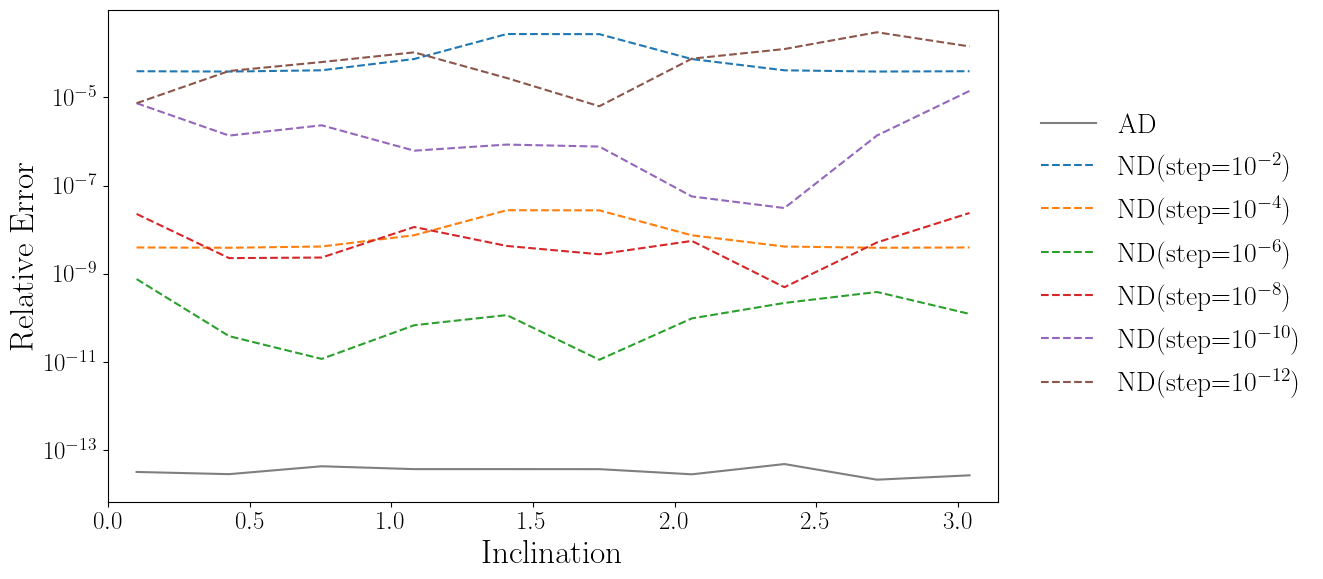

In [16]:
color_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
label_list = [r'ND(step=$10^{-2}$)', r'ND(step=$10^{-4}$)', r'ND(step=$10^{-6}$)', r'ND(step=$10^{-8}$)', r'ND(step=$10^{-10}$)', r'ND(step=$10^{-12}$)']
plt.figure(figsize=[fig_width*1.35,fig_height])
plt.semilogy(iota_array, np.abs((drho_diota_sd-drho_diota_ad)/drho_diota_sd), color='tab:gray', label='AD')
for idx, nd_data in enumerate(drho_diota_nd_list):
    plt.semilogy(iota_array, np.abs((drho_diota_sd-nd_data)/drho_diota_sd), linestyle='dashed', color=color_list[idx], label=label_list[idx])
plt.xlabel("Inclination")
# plt.ylabel(r'${\rm abs}(\frac{\partial \rho}{\partial \iota}|_{\rm SD} - \frac{\partial \rho}{\partial \iota}|_{\rm AD, or ND})$')
# plt.ylabel(r'$\left| \frac{\frac{\partial \rho}{\partial \iota}|_{\rm SD} - \frac{\partial \rho}{\partial \iota}|_{\rm AD, or ND}}{\frac{\partial \rho}{\partial \iota}|_{\rm SD}}\right|$')
plt.ylabel("Relative Error")
plt.xlim(0.0, np.pi)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.savefig("numerical_err_diota_rel.pdf")